Angle in rad: 1.571
Original point: [1 0],  Rotated point: [6.123234e-17 1.000000e+00]


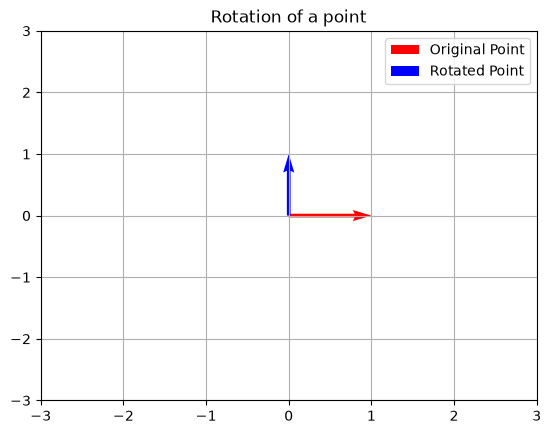

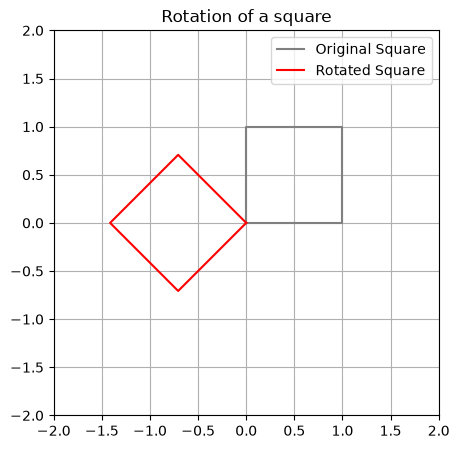

square points: [[0 0]
 [1 0]
 [1 1]
 [0 1]
 [0 0]],  Rotated Rectangle point: [[ 0.00000000e+00  0.00000000e+00]
 [-7.07106781e-01  7.07106781e-01]
 [-1.41421356e+00  1.11022302e-16]
 [-7.07106781e-01 -7.07106781e-01]
 [ 0.00000000e+00  0.00000000e+00]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

"""
#######         Day 1: vectors and vector addition       #######
v1=np.array([4, 3])
v2=np.array([3, 4])
v3=v1 + v2
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='r', label='v1')
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='b', label='v2')
plt.quiver(0, 0, v3[0], v3[1], angles='xy', scale_units='xy', scale=1, color='g', label='v3')
plt.xlim(-10, 10); plt.ylim(-10, 10)
plt.grid(); plt.legend()
plt.title("Two vectors")
plt.show()

def dot_products(a,b):
    total=0
    for i in range(len(a)):
        total+=a[i]*b[i]
    return total

manual_dot=dot_products(v1,v2)
np_dot=np.dot(v1,v2)
print("Manual dot product:", manual_dot)
print("Numpy dot product:", np_dot)
assert manual_dot==np_dot, "Dot products do not match!"



#######         Day2:  Dot products and duality      #######
# Cosine similarity — used constantly in ML (feature similarity, embeddings)
def cosine_similarity(a,b):
    return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))


print(f"Cosine similarity: {cosine_similarity(v1, v2):.3f}")

#Same direction vectors
s1=np.array([1, 1])
s2=np.array([2, 2])
print(f"Cosine similarity (same direction): {cosine_similarity(s1, s2):.3f}")   

#Perpendicular vectors
p1=np.array([1, 0])
p2=np.array([0, 1])
print(f"Cosine similarity (perpendicular): {cosine_similarity(p1, p2):.3f}")    

#Opposite direction vectors
o1=np.array([1, 0])
o2=np.array([-1, 0])
print(f"Cosine similarity (opposite direction): {cosine_similarity(o1, o2):.3f}")   


#######         Day 3 — Matrices as Transformations        #######

# A rotation matrix — this is exactly the math behind camera calibration/extrinsics

angle_rad= np.radians(90)
print(f"Angle in rad: {angle_rad:.3f}" )
rotation_matrix=np.array([
                        [np.cos(angle_rad), -np.sin(angle_rad)], 
                        [np.sin(angle_rad), np.cos(angle_rad)]
                        ])

point=np.array([1,0])
rotated_point=rotation_matrix @ point
print(f"Original point: {point},  Rotated point: {rotated_point}")

fig,ax=plt.subplots()
ax.quiver(0, 0, point[0], point[1], angles='xy', scale_units='xy', scale=1, color='r', label='Original Point')
ax.quiver(0, 0, rotated_point[0], rotated_point[1], angles='xy', scale_units='xy', scale=1, color='b', label='Rotated Point')
ax.set_xlim(-3, 3); ax.set_ylim(-3,3)
ax.legend(); ax.grid(); ax.set_title("Rotation of a point")
plt.show()


#Sqaure points
square_points=np.array([[0,0], [1,0], [1,1],[0,1],[0,0]])
def rotate_rectangle(points, theta_deg):
    angle_rad=np.radians(theta_deg)
    rotation_matrix=np.array([
                        [np.cos(angle_rad), -np.sin(angle_rad)],
                        [np.sin(angle_rad), np.cos(angle_rad)]
                        ])
    return points @ rotation_matrix.T



fig,ax=plt.subplots(figsize=(5,5))    
rotated_rectangle=rotate_rectangle(square_points, 135)
ax.plot(square_points[:,0], square_points[:,1], 'gray', label='Original Square')
ax.plot(rotated_rectangle[:,0], rotated_rectangle[:,1], 'red', label='Rotated Square')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.legend(); ax.grid(); ax.set_title("Rotation of a square");ax.set_aspect('equal')
plt.show()

print(f"square points: {square_points},  Rotated Rectangle point: {rotated_rectangle}")

"""





In [ ]:


#######         Day 4 — Matrix Multiplication From Scratch       #######
def matmul_scratch(A, B):
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape
    assert cols_A == rows_B, "Incompatible shapes"
    result = np.zeros((rows_A, cols_B))
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                result[i][j] += A[i][k] * B[k][j]
    return result

A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

manual = matmul_scratch(A, B)
numpy_result = A @ B
assert np.allclose(manual, numpy_result)
print("Matches NumPy!")
print(manual)

import time

# Bigger matrices this time
A_big = np.random.rand(100, 100)
B_big = np.random.rand(100, 100)

start = time.time()
manual_result = matmul_scratch(A_big, B_big)
manual_time = time.time() - start

start = time.time()
numpy_result = A_big @ B_big
numpy_time = time.time() - start

print(f"Manual (scratch): {manual_time:.4f} sec")
print(f"NumPy (@):        {numpy_time:.4f} sec")
print(f"NumPy is {manual_time/numpy_time:.0f}x faster")



Matches NumPy!
[[19. 22.]
 [43. 50.]]
Manual (scratch): 0.3756 sec
NumPy (@):        0.0003 sec
NumPy is 1313x faster


In [16]:
#####       Day 5 — Eigenvalues & Eigenvectors, Tied to Your Background #####
A=np.array([[2,0],[0,3]])
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors: {eigenvectors}")  

Eigenvalues: [2.+0.j 3.+0.j]
Eigenvectors: [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


In [24]:
A2=np.array([[3,1],[0,2]])
eigenvalues2, eigenvectors2 = np.linalg.eig(A2)
print(f"Eigenvalues: {eigenvalues2}")
print(f"Eigenvectors: {eigenvectors2}")  


Eigenvalues: [3.+0.j 2.+0.j]
Eigenvectors: [[ 1.        +0.j -0.70710678+0.j]
 [ 0.        +0.j  0.70710678+0.j]]


c:\Users\AjayK\Downloads\industrial-ai-journey1\ml-env\Lib\site-packages\matplotlib\transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


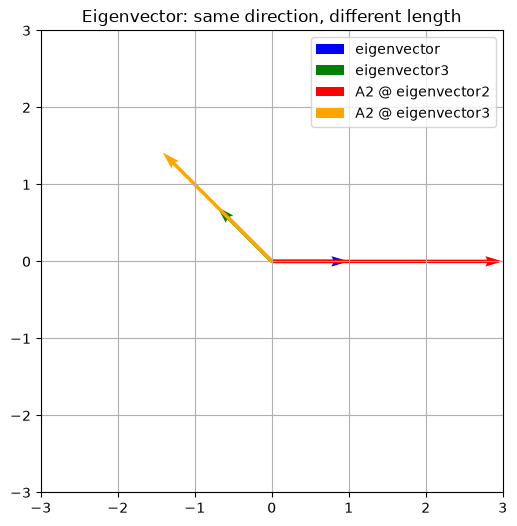

In [27]:
v = eigenvectors2[:, 0]  # first eigenvector
transformed_v = A2 @ v

c = eigenvectors2[:, 1]  # second eigenvector
transformed_c = A2 @ c


fig, ax = plt.subplots(figsize=(6,6))
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='blue', label='eigenvector')
ax.quiver(0, 0, c[0], c[1], angles='xy', scale_units='xy', scale=1, color='green', label='eigenvector3')
ax.quiver(0, 0, transformed_v[0], transformed_v[1], angles='xy', scale_units='xy', scale=1, color='red', label='A2 @ eigenvector2')
ax.quiver(0, 0, transformed_c[0], transformed_c[1], angles='xy', scale_units='xy', scale=1, color='orange', label='A2 @ eigenvector3')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.legend(); ax.grid(); ax.set_aspect('equal')
ax.set_title("Eigenvector: same direction, different length")
plt.show()

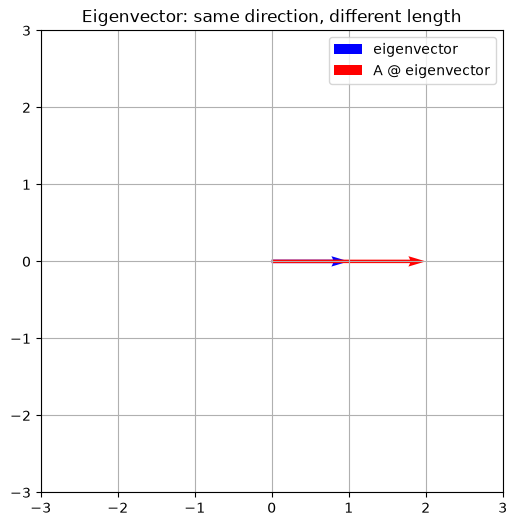

In [23]:
v = eigenvectors[:, 0]  # first eigenvector
transformed_v = A @ v

fig, ax = plt.subplots(figsize=(6,6))
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='blue', label='eigenvector')
ax.quiver(0, 0, transformed_v[0], transformed_v[1], angles='xy', scale_units='xy', scale=1, color='red', label='A @ eigenvector')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.legend(); ax.grid(); ax.set_aspect('equal')
ax.set_title("Eigenvector: same direction, different length")
plt.show()

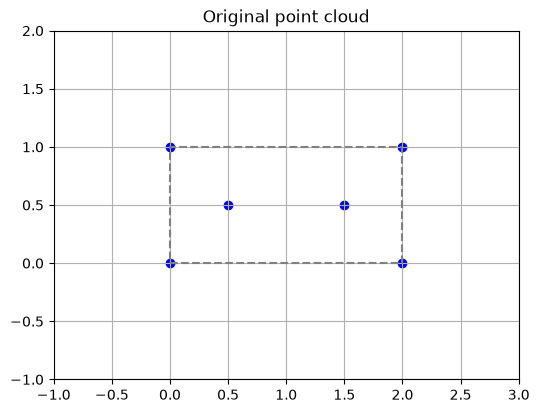

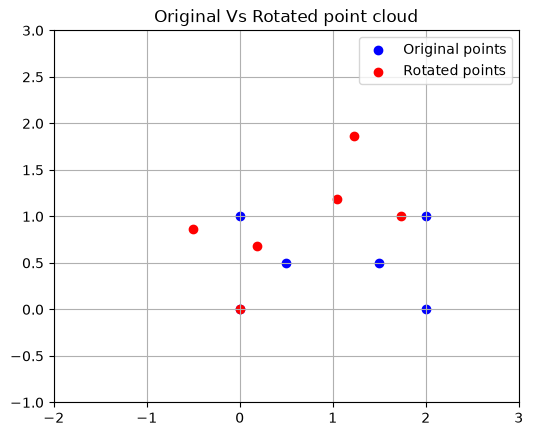

Centroid: [1.  0.5]
Centered points:
[[-1.  -0.5]
 [ 1.  -0.5]
 [ 1.   0.5]
 [-1.   0.5]
 [-0.5  0. ]
 [ 0.5  0. ]]
Covariance matrix:
[[0.9 0. ]
 [0.  0.2]]
Eigenvalues: [0.2 0.9]
Principle axis directions:
[[0. 1.]
 [1. 0.]]
Mean: 3.0
Variance: 2.0


In [ ]:


 ######       Day 6-7 — Consolidation Project: "Rotate and Analyze a Point Cloud"      #####  
# A rough rectangle with a couple of extra "feature" points, like a part outline
points = np.array([
                    [0, 0], [2, 0], [2, 1], [0, 1], 
                    [0.5, 0.5], [1.5, 0.5]
                    ])

plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], color='blue')
plt.plot(points[:4,0].tolist()+[points[0,0]], points[:4,1].tolist()+[points[0,1]], 'gray', linestyle='--')
plt.xlim(-1, 3); plt.ylim(-1, 2)
plt.grid(); plt.gca().set_aspect('equal')
plt.title("Original point cloud")
plt.show()

##Step 2 — Rotate the whole point set (reusing Day 3's skill)
def rotate_points(points, theta_deg):
    angle_rad=np.radians(theta_deg)
    rotation_matrix=np.array([
                        [np.cos(angle_rad), -np.sin(angle_rad)],
                        [np.sin(angle_rad), np.cos(angle_rad)]
                        ])
    return points @ rotation_matrix.T   

Rotated_points = rotate_points(points, 30)
plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], color='blue', label = 'Original points')
plt.scatter(Rotated_points[:,0], Rotated_points[:,1], color='red', label = 'Rotated points')
plt.xlim(-2, 3); plt.ylim(-1, 3)
plt.grid(); plt.legend(); plt.gca().set_aspect('equal')
plt.title("Original Vs Rotated point cloud")
plt.show()


##Step 3 — Center the points around their centroid
centroid = points.mean(axis=0)
center_points = points - centroid
print(f"Centroid: {centroid}")
print(f"Centered points:\n{center_points}")

##Step 4 — Find the principal axes (this is where Day 5 pays off)
cov_matrix = np.cov(center_points.T)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
print(f"Covariance matrix:\n{cov_matrix}")
print(f"Eigenvalues: {eigenvalues}")
print(f"Principle axis directions:\n{eigenvectors}")





Mean: 3.0
Variance: 2.0


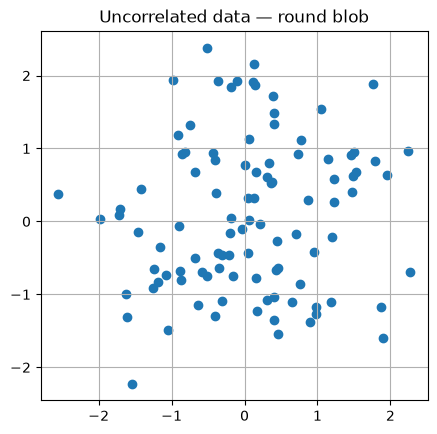

[[1.02608749 0.11769063]
 [0.11769063 1.08134929]]


In [ ]:
##Practice example
x = np.array([1, 2, 3, 4, 5])
print(f"Mean: {x.mean()}")
print(f"Variance: {np.var(x)}")



np.random.seed(0)
x = np.random.normal(0, 1, 100)   # random, mean 0
y = np.random.normal(0, 1, 100)   # random, mean 0, unrelated to x

plt.scatter(x, y)
plt.gca().set_aspect('equal')
plt.title("Uncorrelated data — round blob")
plt.grid()
plt.show()

cov_matrix = np.cov(x, y)
print(cov_matrix)

### 


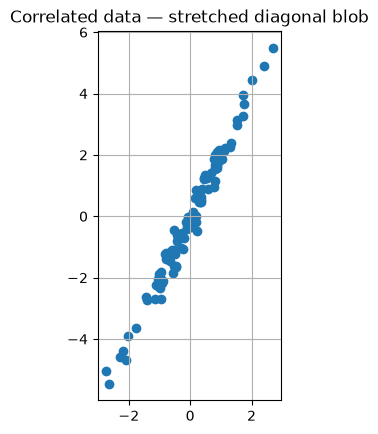

[[1.08659421 2.20332168]
 [2.20332168 4.56093192]]
Eigenvalues: [0.01798652+0.j 5.62953962+0.j]
Eigenvectors:
[[-0.89976112+0.j -0.43638279+0.j]
 [ 0.43638279+0.j -0.89976112+0.j]]


c:\Users\AjayK\Downloads\industrial-ai-journey1\ml-env\Lib\site-packages\matplotlib\transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


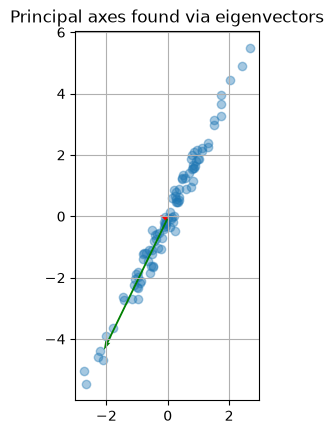

In [25]:
x = np.random.normal(0, 1, 100)
y = 2*x + np.random.normal(0, 0.3, 100)  # y roughly follows x, with noise

plt.scatter(x, y)
plt.gca().set_aspect('equal')
plt.title("Correlated data — stretched diagonal blob")
plt.grid()
plt.show()

cov_matrix = np.cov(x, y)
print(cov_matrix)

eigvals, eigvecs = np.linalg.eig(cov_matrix)
print(f"Eigenvalues: {eigvals}")
print(f"Eigenvectors:\n{eigvecs}")

# Plot the blob with eigenvector directions drawn as arrows
mean_point = np.array([x.mean(), y.mean()])
plt.scatter(x, y, alpha=0.4)
for i in range(2):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i]) * 2  # scale for visibility
    plt.quiver(*mean_point, *vec, angles='xy', scale_units='xy', scale=1,
               color='red' if i==0 else 'green', width=0.01)
plt.gca().set_aspect('equal')
plt.title("Principal axes found via eigenvectors")
plt.grid()
plt.show()